In [2]:
import sys
sys.path.append('../src')

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

import matplotlib.pyplot as plt
plt.style.core.USER_LIBRARY_PATHS.append('/gscratch/matsulab/utils/ctleelab-mpl-utilities/ctleelab_plothelper')
plt.style.reload_library()

sys.path.append('../../../utils')
from fonts.mpl_fonts import set_arial_font
set_arial_font()

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

[mpl_fonts] Using font: Arial
[mpl_fonts] Font dir: /mmfs1/gscratch/matsulab/utils/fonts


In [5]:
## To reload

import importlib
import pinn.normal_curves as normal_curves
importlib.reload(normal_curves)

<module 'pinn.normal_curves' from '/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/notebooks/../src/pinn/normal_curves.py'>

In [3]:
## CALCULATE NORMAL, CURVATURES, and FORCE ##

# from pinn.normal_curves import calc_norm_curv, write_vtk_polydata
from pinn.normal_curves import write_vtk_polydata, calc_norm_curv_K_force

import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints

for missing in [0.0]:
    for lambda_2 in [10]:
    # for lambda_2 in [10, 1, 0]:
        print(missing, lambda_2)

        # ==== Parameters =====
        lambda_1 = 100000
        # lambda_2 = 0
        lambda_3 = 100000
        lambda_4 = 100
        lambda_5 = 1
        lambda_6 = 1
        shape = "biconcave"
        step = 10000
        additive = 0.00
        # missing  = 0.6
        str_add = f"{additive:.2f}".replace('.', '')
        str_miss = f"{missing:.1f}".replace('.', '')
        version  = "data_0123"
        
        # ==== Load checkpoint data =====
        checkpoint_data = {}
        # checkpoint_dir = f"../outputs/logs/{shape}/{version}/a{str_add}_m{str_miss}/lambda_{lambda_1}_{lambda_2}_{lambda_3}_cont"
        # checkpoint_dir = f"../outputs/logs/{shape}/{version}/a{str_add}_m{str_miss}/lambda_{lambda_1}_{lambda_2}_{lambda_3}_test"
        # checkpoint_dir = f"../outputs/logs/{shape}/{version}/a{str_add}_m{str_miss}/lambda_{lambda_1}_{lambda_2}_{lambda_3}_{lambda_4}_contcont"
        # checkpoint_dir = f"../outputs/logs/{shape}/{version}/a{str_add}_m{str_miss}/lambda_{lambda_1}_{lambda_2}_{lambda_3}_{lambda_4}_50000"
        checkpoint_dir = f"../outputs/logs/{shape}/{version}/a{str_add}_m{str_miss}/cont4_lambda_{lambda_1}_{lambda_2}_{lambda_3}_{lambda_4}_{lambda_5}_{lambda_6}"
        # checkpoint_dir = f"../outputs/logs/{shape}/{version}/a01_w00_t60/lambda_{lambda_1}_{lambda_2}_{lambda_3}_cont"
        # checkpoint_dir = f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}_{lambda_3}_cont"
        # checkpoint_dir = f"../outputs/logs/jrc_cos7-1b/{shape}/lambda_{lambda_1}_{lambda_2}_{lambda_3}_cont"
        checkpoint_path = os.path.abspath(f"{checkpoint_dir}/checkpoint_{step}")
        checkpoint_data = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

        print(checkpoint_path)
        
        # verts, faces, norms, curvs = calc_norm_curv(checkpoint_data)
        # # verts, faces, norms, curvs = calc_norm_curv(checkpoint_data, x_range=(-0.3,0.3))
        # # verts, faces, norms, curvs = calc_norm_curv(checkpoint_data, x_range=(-0.5,0.42))

        # verts, faces, norms, curvs, gauss, force = calc_norm_curv_K_force(checkpoint_data)
        verts, faces, norms, curvs, gauss, force = calc_norm_curv_K_force(checkpoint_data, grid_size=128)
        
        # ## ==== Save NPZ =====
        # npz_path = f"{checkpoint_dir}/verts_{step}.npz"
        # np.savez(npz_path, verts=verts, faces=faces, norms=norms, curvs=curvs)
        
        # ## ==== Save VTK =====
        # vtk_path = f"{checkpoint_dir}/verts_{step}.vtk"
        # write_vtk_polydata(vtk_path, verts, faces, point_vectors={"Normal": norms}, point_scalars={"Curvature": curvs})\

        ## ==== Save NPZ =====
        npz_path = f"{checkpoint_dir}/verts_{step}.npz"
        np.savez(npz_path, verts=verts, faces=faces, norms=norms, curvs=curvs, gauss=gauss, force=force)
        
        ## ==== Save VTK =====
        vtk_path = f"{checkpoint_dir}/verts_{step}.vtk"
        write_vtk_polydata(vtk_path, verts, faces, 
                           point_vectors={"Normal": norms, "Force": force}, 
                           point_scalars={"MeanCurvature": curvs, "GaussianCurvature": gauss})

0.0 10
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/data_0123/a000_m00/cont4_lambda_100000_10_100000_100_1_1/checkpoint_10000


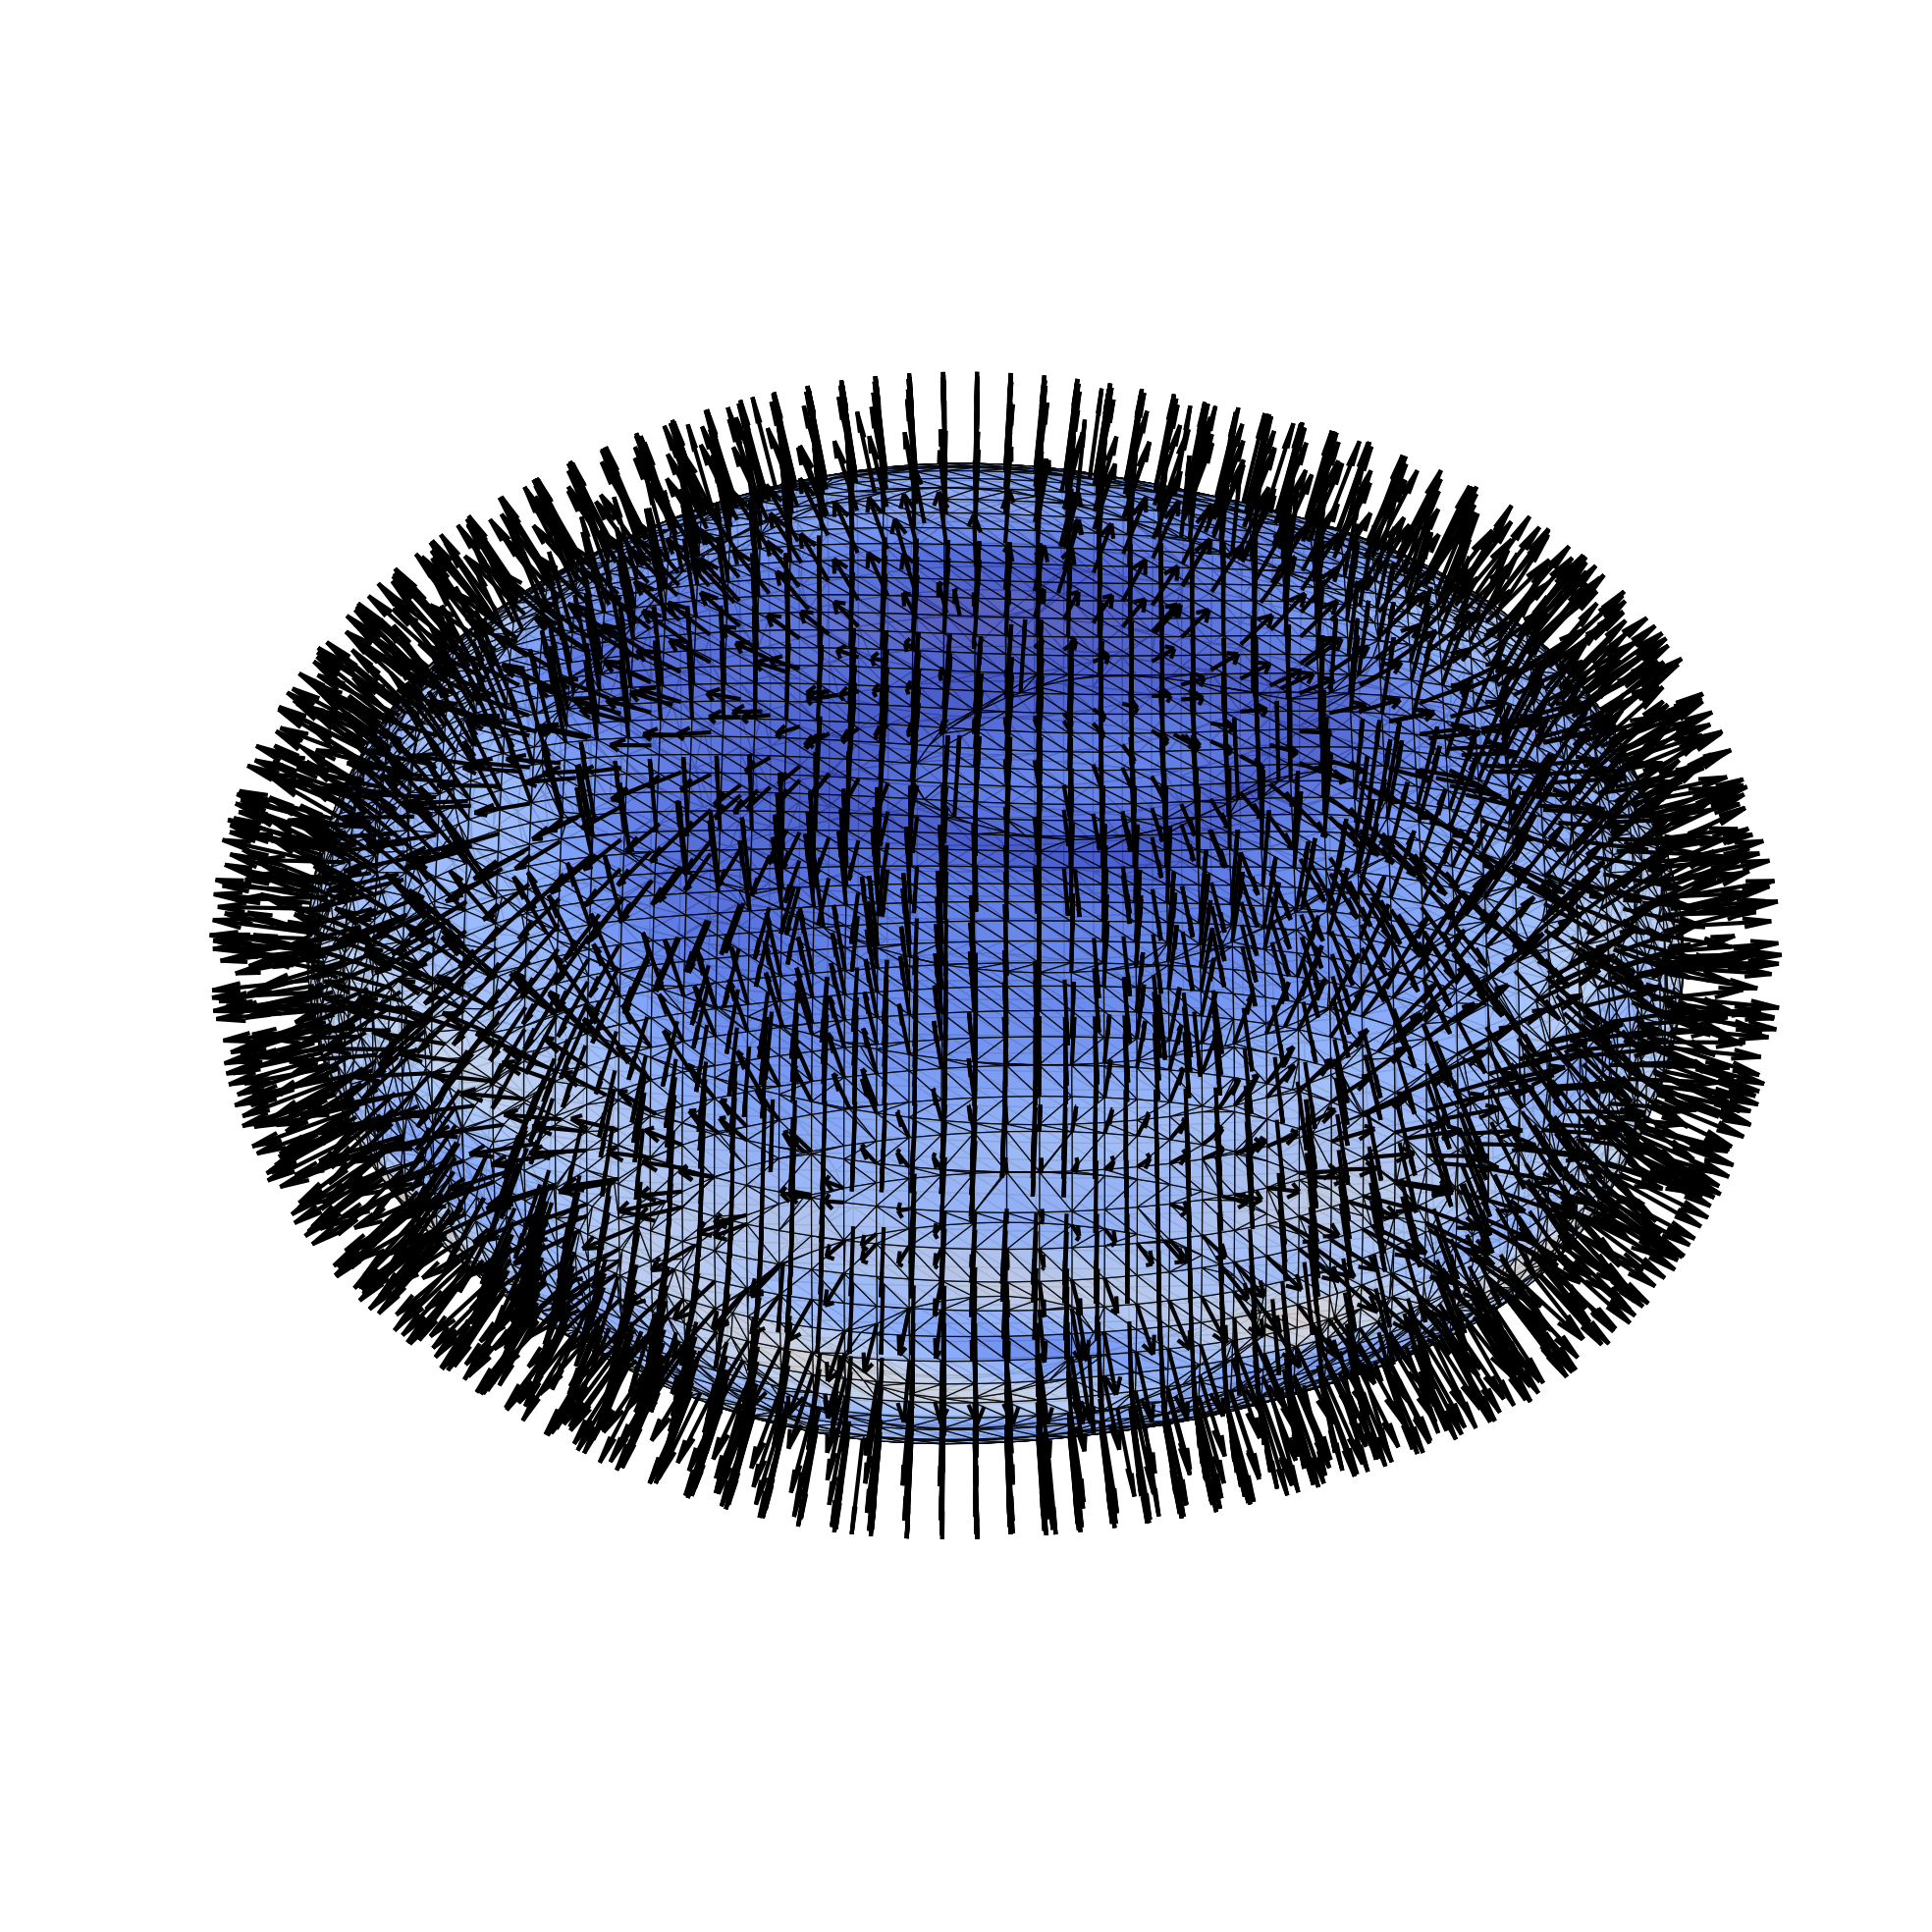

In [25]:
## STATIC PLOT ##

from pinn.normal_curves import plot_norm_curv, load_mesh_npz
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints

# ==== Parameters =====
# lambda_1 = 100000
# lambda_2 = 1
# lambda_3 = 100000
# shape = "czii_gl_1"
# step = 10000
# additive = 0.15
# missing  = 0.6
# str_add  = str(additive).replace('.', '')
# str_miss = str(missing).replace('.', '')
# version  = "data_0123"

# ==== Load npz data =====
checkpoint_dir = f"../outputs/logs/{shape}/{version}/a{str_add}_m{str_miss}/lambda_{lambda_1}_{lambda_2}_{lambda_3}_cont"
# checkpoint_dir = f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}_{lambda_3}_cont"
npz_path = f"{checkpoint_dir}/verts_{step}.npz"
# npz_path = f"../data/synthetic/gt/gt_refined_{shape}.npz"

verts, faces, norms, curvs = load_mesh_npz(npz_path)
# curvs = curvs * 2.0


# ==== Plot Figure =====
plt.style.reload_library()
with plt.style.context(["base", "transparent"]):
    fig = plt.figure(figsize=(4, 4))
    ax = fig.add_subplot(111, projection="3d")
    
    plot_norm_curv(ax, verts, faces, norms, curvs,
                    n_quiver=3000,        # number of arrows to draw 1000
                    quiver_length=0.1,    # arrow length in plot units
                    norm_direction=-1.0,
                    # clim=(0.0, 8.0),
                    clim=(0.0, 15.0),
                    show_colorbar=False,
                  )
    
    # ax.view_init(elev=30, azim = 45, roll=-90-30) # for bud_04
    ax.view_init(elev=50, azim = 0, roll=-180)  # for biconcave
    # ax.view_init(elev=100, azim = 160, roll=45)
    # ax.view_init(elev=20, azim = 0, roll=0)
    # ax.view_init(elev=150, azim = 0, roll=0)
    
    # fig.savefig(f"../outputs/figs/v_0127/synth_3d_{shape}_{lambda_2}_a{str_add}_m{str_miss}.png", bbox_inches="tight", pad_inches=0.0, transparent=True,)
    # fig.savefig(f"../outputs/figs/v_0127/synth_3d_{shape}_gt.png", bbox_inches="tight", pad_inches=0.0, transparent=True,)
    # fig.savefig(f"../outputs/figs/v_0127/cbar_3d.pdf", bbox_inches="tight", pad_inches=0.0, transparent=True,)
    plt.show()


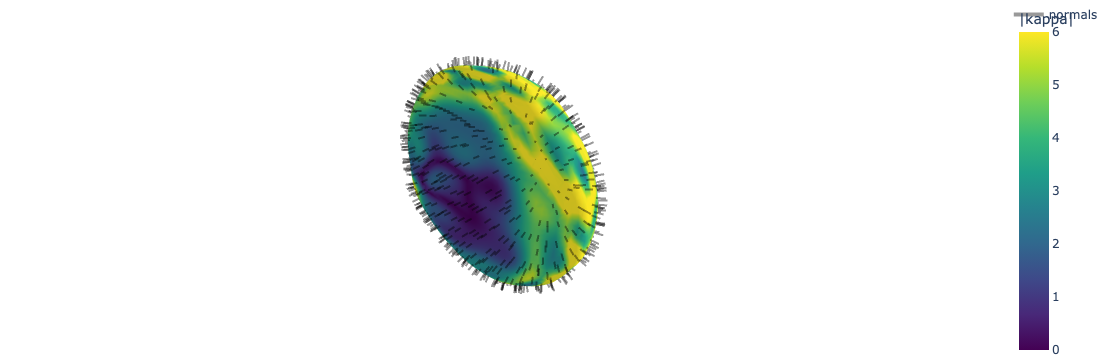

In [42]:
## INTERACTIVE PLOT ##

from pinn.normal_curves import interactive_isosurface_plot

# ==== Parameters =====
lambda_1 = 100000
lambda_2 = 10
lambda_3 = 100000
shape = "biconcave"
step = 10000
additive = 0.15
missing  = 0.6
str_add  = str(additive).replace('.', '')
str_miss = str(missing).replace('.', '')
version  = "data_0123"

# ==== Load checkpoint data =====
checkpoint_data = {}
checkpoint_dir = f"../outputs/logs/{shape}/{version}/a{str_add}_m{str_miss}/lambda_{lambda_1}_{lambda_2}_{lambda_3}_cont/checkpoint_{step}"
# checkpoint_dir = f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}_{lambda_3}/checkpoint_{step}"
checkpoint_path = os.path.abspath(checkpoint_dir)
checkpoint_data = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)


fig, verts, faces, norms, kappa = interactive_isosurface_plot(
    checkpoint_data,
    grid_size=64,
    
    compute_normals=True,
    n_cone=1000, 
    cone_length=0.05,
    cone_opacity=0.4,
    norm_direction=-1,
    
    compute_curvature=True,
    abs_curvature=True,
    colorscale="Viridis",
    clim=(0, 6),          # color range
    show_colorbar=True,
    mesh_opacity=1,
)
fig.show()



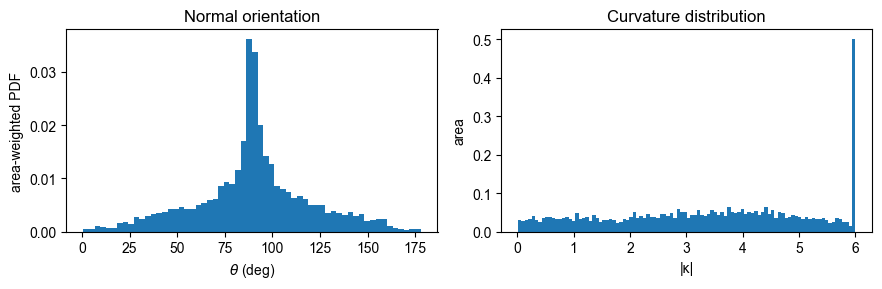

In [41]:
## PLOT HISTOGRAMS ##

from pinn.normal_curves import plot_curvature_hist, plot_normals_hist

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(9, 3),
    sharey=False,
)

plot_normals_hist(
    norms,
    verts,
    faces,
    ref_dir=(0, 0, 1),
    bins=60,
    ax=ax1,
)

plot_curvature_hist(
    curvs,
    verts=verts,
    faces=faces,
    bins=100,
    abs_val=True,
    clip=(0, 6),
    area_weighted=True,
    title="Curvature distribution",
    ax=ax2,
)

plt.tight_layout()
plt.show()



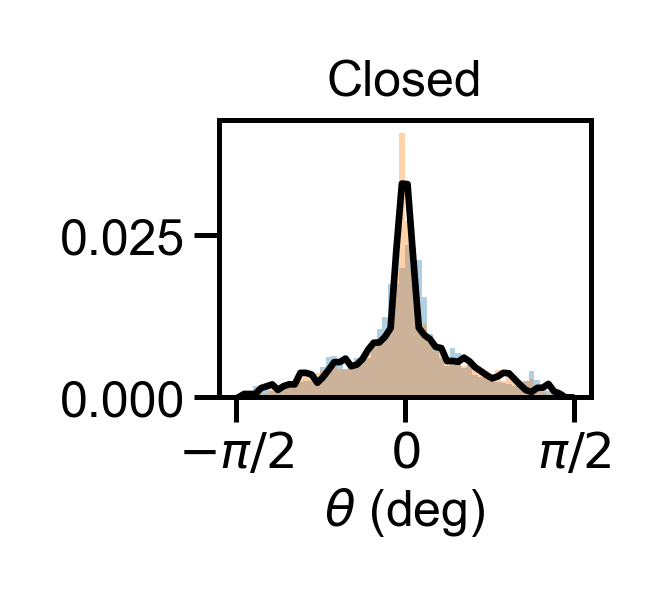

In [10]:
from pinn.normal_curves import plot_normals_hist_2exp_vs_gt
import numpy as np
import matplotlib.pyplot as plt

# ---- helper: load one mesh npz ----
def load_mesh_npz(npz_path, keys=("verts", "faces", "norms")):
    dat = np.load(npz_path, allow_pickle=True)
    # keys can be changed if your npz uses different names
    verts = dat[keys[0]]
    faces = dat[keys[1]]
    norms = dat[keys[2]]
    return norms, verts, faces


# ==== Parameters =====
lambda_1 = 100000
lambda_2_list = [0, 10]
lambda_3 = 100000
shape = "biconcave"
step = 10000
additive = 0.15
missing  = 0.6
str_add  = str(additive).replace('.', '')
str_miss = str(missing).replace('.', '')
version  = "data_0123"
SHAPE_TITLE_MAP = {
    "biconcave": "Closed",
    "bud_04": "Open",
    "multi": "Multiple",
}
title_shape = SHAPE_TITLE_MAP.get(shape, shape)

# ==== Load TWO experiment meshes (lambda_2 = 0 and 10) ====
exp = {}  # exp[lambda_2] = (norms, verts, faces)

for lambda_2 in lambda_2_list:
    checkpoint_dir = (
        f"../outputs/logs/{shape}/{version}/a{str_add}_m{str_miss}"
        f"/lambda_{lambda_1}_{lambda_2}_{lambda_3}_cont"
    )
    npz_path = f"{checkpoint_dir}/verts_{step}.npz"
    norms, verts, faces = load_mesh_npz(npz_path, keys=("verts", "faces", "norms"))
    exp[lambda_2] = (norms, verts, faces)

# unpack
norms_1, verts_1, faces_1 = exp[lambda_2_list[0]]
norms_2, verts_2, faces_2 = exp[lambda_2_list[1]]

# ==== Load ground truth mesh ====
gt_npz_path = f"../data/../data/synthetic/gt/gt_{shape}.npz"
norms_g, verts_g, faces_g = load_mesh_npz(gt_npz_path, keys=("verts", "faces", "norms"))

# ==== Plot Normals ====
plt.style.reload_library()
with plt.style.context(["base", "transparent"]):
    fig, ax = plt.subplots(figsize=(0.8, 0.6))
    plot_normals_hist_2exp_vs_gt(
        norms_1, verts_1, faces_1,
        norms_2, verts_2, faces_2,
        norms_g, verts_g, faces_g,
        ref_dir=(0, 0, 1),
        bins=60,
        ax=ax,
        labels=(f"λ2={lambda_2_list[0]}", f"λ2={lambda_2_list[1]}", "GT"),
        # title=f"Normal Orientation ({title_shape})", 
        title=f"{title_shape}", 
        show_legend=False,
    )
    plt.savefig(f"../outputs/figs/v_0127/synth_norm_{shape}_a{str_add}_m{str_miss}.png", bbox_inches="tight")
    plt.show()


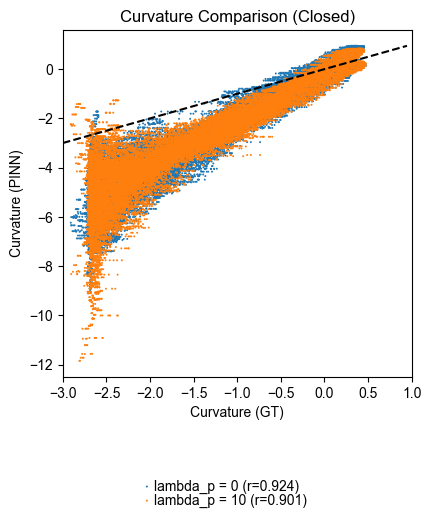

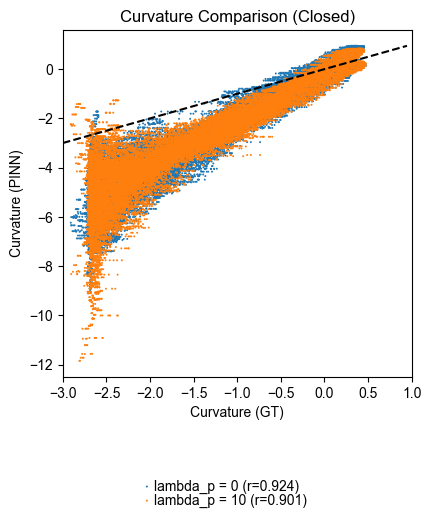

In [29]:
from pinn.normal_curves import load_mesh_npz, match_and_plot_two_data
import numpy as np

# ==== Parameters =====
lambda_1 = 100000
lambda_2_list = [0, 10]
lambda_3 = 100000
shape = "biconcave"
step = 10000
additive = 0.00
missing  = 0.0
str_add = f"{additive:.2f}".replace('.', '')
str_miss = f"{missing:.1f}".replace('.', '')
version  = "data_0123"

SHAPE_TITLE_MAP = {
    "biconcave": "Closed",
    "bud_04": "Open",
    "multi": "Multiple",
}

# ==== Load npz data =====
# GROUND TRUTH
npz_path = f"../data/synthetic/gt/gt_refined_{shape}.npz"
verts_gt, faces_gt, norms_gt, curvs_gt, gauss_gt = load_mesh_npz(npz_path)
curvs_gt = np.abs(curvs_gt)
# theta_gt = np.arccos(norms_gt @ (0,0,1))
theta_gt = np.arccos(np.abs(norms_gt @ (0,0,1)))

# PINN RESULTS
verts_pf = {}; curvs_pf = {}; theta_pf = {}; gauss_pf = {}
for lambda_2 in lambda_2_list:
    checkpoint_dir = f"../outputs/logs/{shape}/{version}/a{str_add}_m{str_miss}/lambda_{lambda_1}_{lambda_2}_{lambda_3}_cont"
    npz_path = f"{checkpoint_dir}/verts_{step}.npz"
    verts, faces, norms, curvs, gauss = load_mesh_npz(npz_path)
    curvs = np.abs(curvs) * 0.5
    # theta = np.arccos(norms @ (0,0,1))
    theta = np.arccos(np.abs(norms @ (0,0,1)))
    verts_pf[lambda_2] = verts; curvs_pf[lambda_2] = curvs; theta_pf[lambda_2] = theta; gauss_pf[lambda_2] = gauss
    
title_shape = SHAPE_TITLE_MAP.get(shape, shape)

# match_and_plot_two_data(verts_gt, theta_gt, 
#                         verts_pf[0], theta_pf[0], 
#                         verts_pf[10], theta_pf[10], 
#                         # xlim=(0,1),
#                         xlabel="Angle (GT)",
#                         ylabel="Angle (PINN)",
#                         labels=("lambda_p = 0", "lambda_p = 10"),
#                         title=f"Normal Vector Comparison ({title_shape})",
#                        )

# match_and_plot_two_data(verts_gt, curvs_gt, 
#                         verts_pf[0], curvs_pf[0], 
#                         verts_pf[10], curvs_pf[10], 
#                         # xlim=(0,5),
#                         xlim = (0, np.max(curvs_gt)),
#                         xlabel="Curvature (GT)",
#                         ylabel="Curvature (PINN)",
#                         labels=("lambda_p = 0", "lambda_p = 10"),
#                         title=f"Curvature Comparison ({title_shape})",
#                        )

match_and_plot_two_data(verts_gt, gauss_gt, 
                        verts_pf[0], gauss_pf[0],
                        verts_pf[10], gauss_pf[10],
                        xlim=(-3,1),
                        xlabel="Curvature (GT)",
                        ylabel="Curvature (PINN)",
                        labels=("lambda_p = 0", "lambda_p = 10"),
                        title=f"Curvature Comparison ({title_shape})",
                       )

In [56]:
norms_gt @ (0,0,1)

array([-0.00075124,  0.00442054,  0.00793196, ..., -0.0088003 ,
       -0.00404348, -0.00046698], shape=(27756,))